# Extended Guinier fits: Zheng & Best (2018)

Reference: https://doi.org/10.1016/j.jmb.2018.03.007, equations 5 and 6.

The model is ln(I/I0) = -(q Rg)^2/3 + 0.0479 (nu - 0.212) (q Rg)^4.
Rg = sqrt[gamma(gamma+1)/(2(gamma+2nu)(gamma+2nu+1))] b N^nu,
with gamma=1.1615, b=5.5 Angstrom, and N=number of residues minus one.
The free parameters are I0 and nu; Rg follows from nu. This is the paper's
coupled single-chain model, not an unconstrained polynomial fit.

We use the supplied 120-residue construct (119 peptide bonds), with a
118-residue sensitivity calculation. WT and AA have the same length.
Weighted least squares is performed in intensity space with the supplied
diagonal errors; unlike a log-intensity fit this can retain negative observations.
The objective implementation differs from a weighted log-space regression.
No smoothing, positivity clipping, constant-background fitting or Rg target is used.

For each curve, scan every measured upper q endpoint through 0.12 Angstrom^-1
and retain the largest endpoint with fitted qmax Rg <= 2. Primary qmin=0.012;
sensitivity qmin=0.010, 0.015 and 0.020. At least eight points and six >3 sigma
positive intensities are required. The numerical nu bounds are 0.2–0.8; boundary
solutions are rejected. These are numerical guards, not validation of all nu values.
All scans are retained, so fit-range dependence is visible. The selected maximum
range is not optimized for chi-square. Input baselines/decomposition are unchanged.

| Curve | Standard Guinier, q=0.012–0.030 | Extended Rg | Extended qmax |
|---|---:|---:|---:|
| WT average | 28.60 | 26.49 | 0.074 |
| WT main candidate | 27.42 | 25.75 | 0.076 |
| AA average | 32.15 | 31.73 | 0.062 |
| AA main candidate | 31.80 | 31.23 | 0.064 |
| WT earlier component | unstable | 40.87 (exploratory) | 0.048 |
| AA secondary component | unsupported | no supported fit | — |

Rg units are Angstrom; q units are inverse Angstrom. Broader fitting windows and
model assumptions change these values; this is not a replacement of the earlier
measurements. Although the curvature term raises Rg at a fixed fit interval,
using a broader interval can yield a smaller fitted Rg, as seen here.

WT shoulder: fitted Rg spans 37.56–43.26 Angstrom over qmin choices; primary
reduced chi-square is 2.44 and the lowest-q excess is not fully described.
The assumed 120-residue single-chain relation is not validated for an oligomer
or mixture. This result is a model diagnostic, not identification or reliable
mass/stoichiometry determination. AA's secondary curve remains unsupported.
IDP curvature by itself is not evidence of contamination.

The 100 stored full-decomposition perturbations are refitted for average and main
component at the fixed selected window. Their percentile intervals are conditional
on the existing baseline/support/model and do not incorporate model error or
fit-window selection uncertainty. Original facility covariance is unknown. Fit
weights are diagonal even though EFA can correlate q points. Shoulder errors
condition on fixed elution profiles; no full shoulder bootstrap is available.
Small fit standard errors must not be treated as total uncertainties.

Reproduce with `python extended_guinier.py` or execute the accompanying notebook.
The input NPZ files are copies of the prior decomposition audit, not new data.
Synthetic exact-recovery validation checks the formula, units and chain length.


In [1]:
from extended_guinier import run
results=run()

In [2]:
from IPython.display import display, Markdown
lines=['| Curve | Extended Rg (Å) | qmax Rg | χ²/dof |','|---|---:|---:|---:|']
for k,v in results.items():
 r=v['primary']
 lines.append(f"| {k} | {r['Rg']:.2f} | {r['qRgmax']:.2f} | {r['chi2_reduced']:.2f} |" if r else f'| {k} | unsupported | — | — |')
display(Markdown('\n'.join(lines)))

| Curve | Extended Rg (Å) | qmax Rg | χ²/dof |
|---|---:|---:|---:|
| WT_092025_average | 26.49 | 1.96 | 1.39 |
| WT_092025_candidate | 25.75 | 1.96 | 0.83 |
| WT_092025_other | 40.87 | 1.96 | 2.44 |
| AA_052026_average | 31.73 | 1.97 | 1.98 |
| AA_052026_candidate | 31.23 | 2.00 | 1.36 |
| AA_052026_other | unsupported | — | — |

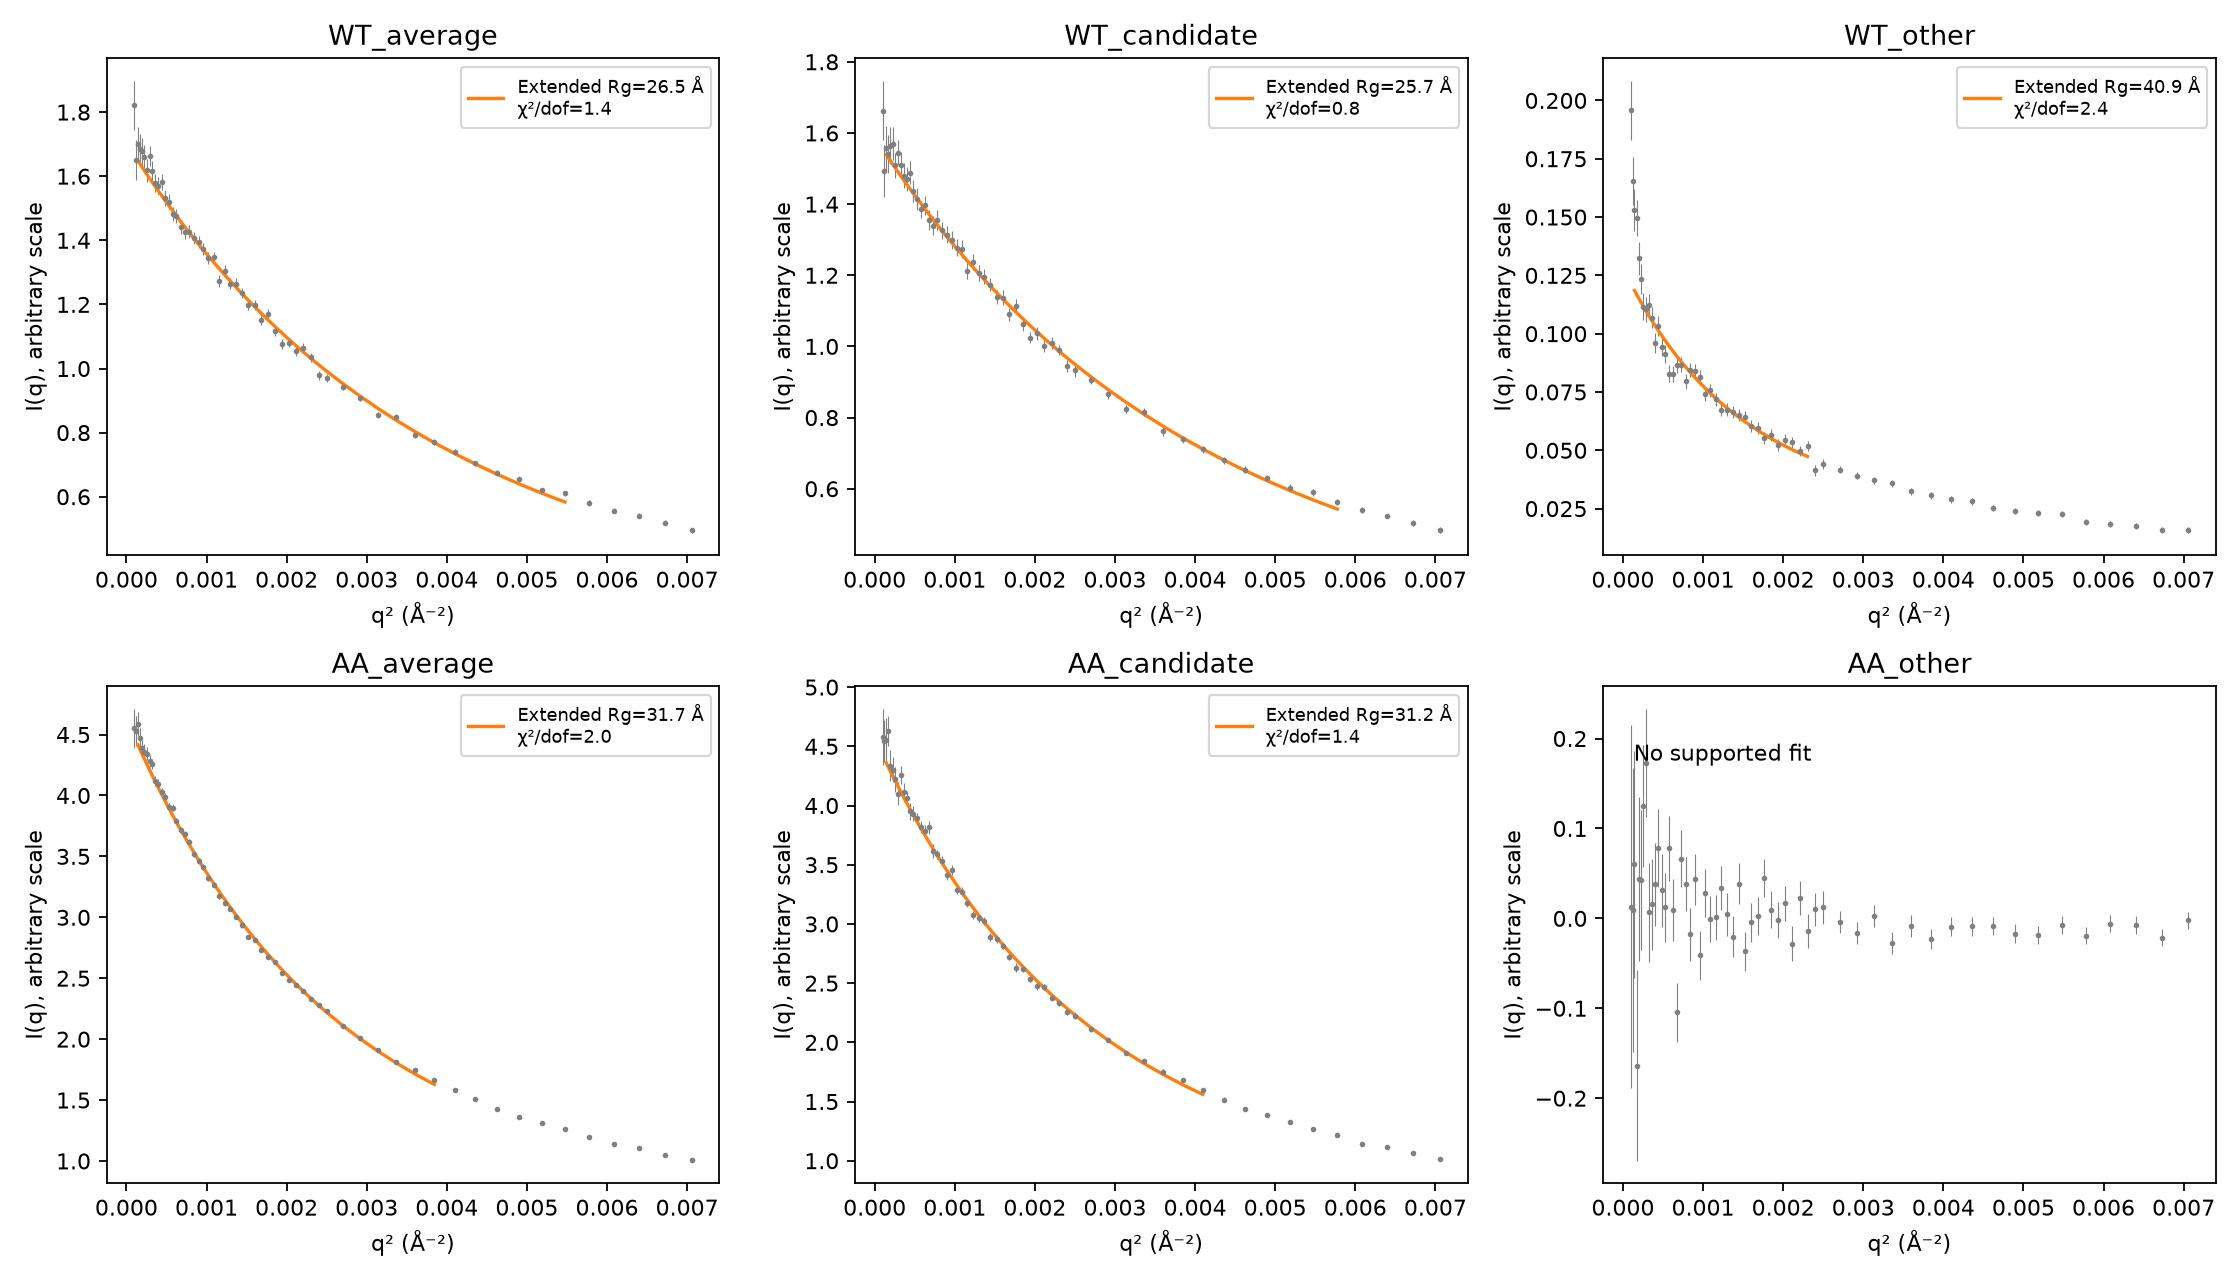

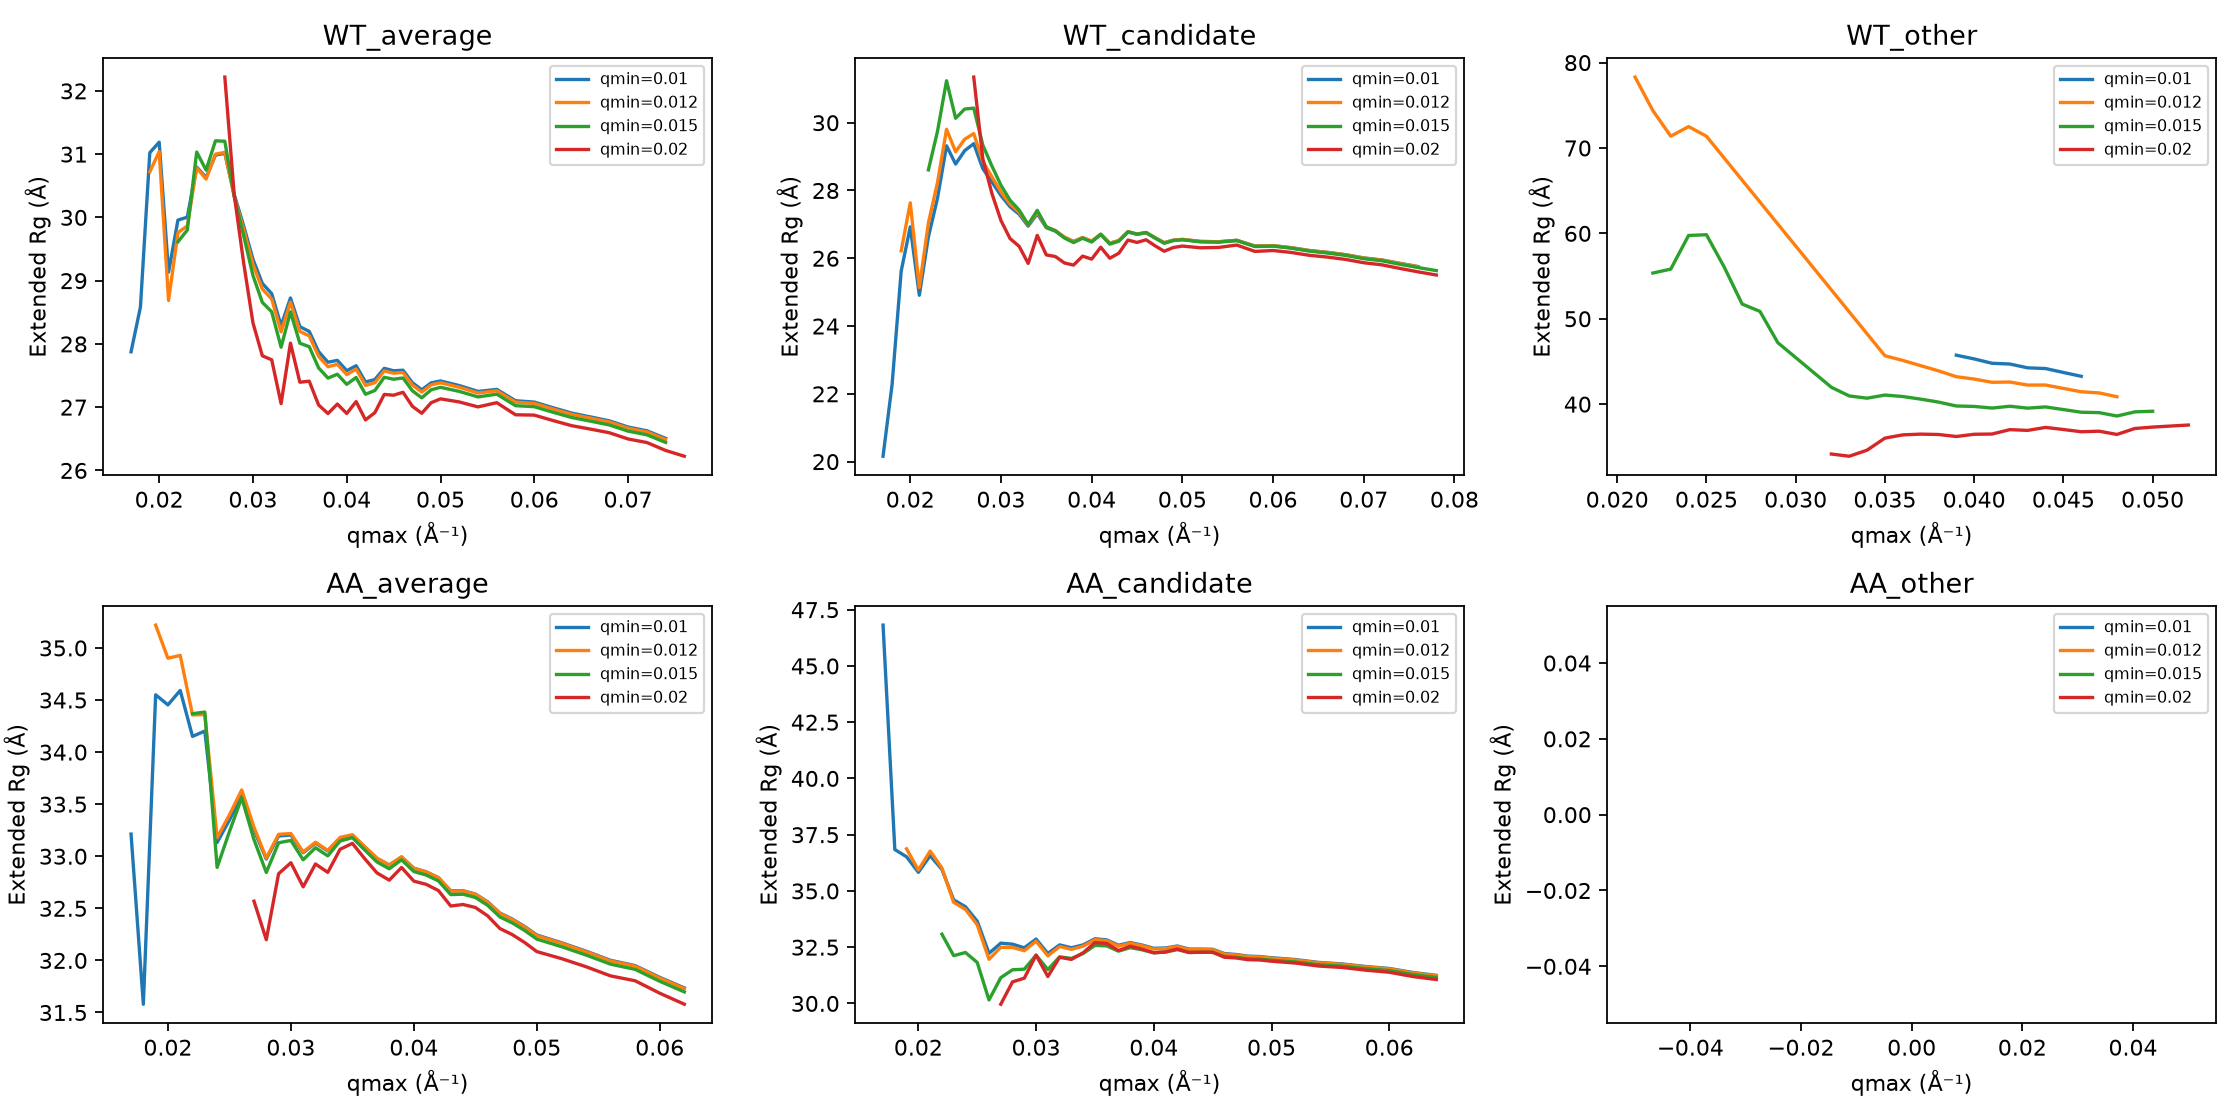

In [3]:
from IPython.display import Image, display
display(Image('extended_fits.png'))
display(Image('fit_range_sensitivity.png'))

In [4]:
{k: {q: x['Rg'] if x else None for q,x in v['qmin_sensitivity'].items()} for k,v in results.items()}

{'WT_092025_average': {'0.01': 26.507421186879984,
  '0.012': 26.489480301979764,
  '0.015': 26.4426570820762,
  '0.02': 26.2240719524176},
 'WT_092025_candidate': {'0.01': 25.754846815058293,
  '0.012': 25.74916667765796,
  '0.015': 25.635693120359985,
  '0.02': 25.50617789879013},
 'WT_092025_other': {'0.01': 43.25940153157513,
  '0.012': 40.86640256343632,
  '0.015': 39.171454417989416,
  '0.02': 37.55530378717199},
 'AA_052026_average': {'0.01': 31.735834665861343,
  '0.012': 31.72933758285837,
  '0.015': 31.69754102329185,
  '0.02': 31.579351924659075},
 'AA_052026_candidate': {'0.01': 31.247525609680743,
  '0.012': 31.228633800862625,
  '0.015': 31.156132791612627,
  '0.02': 31.062663809319783},
 'AA_052026_other': {'0.01': None, '0.012': None, '0.015': None, '0.02': None}}

### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

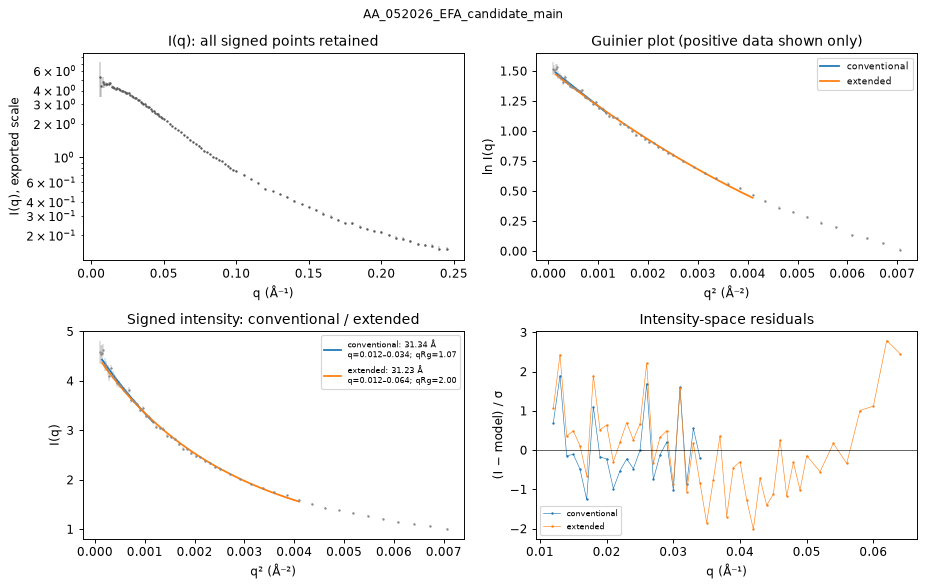

Component identity and physical validity are not established by a converged fit.

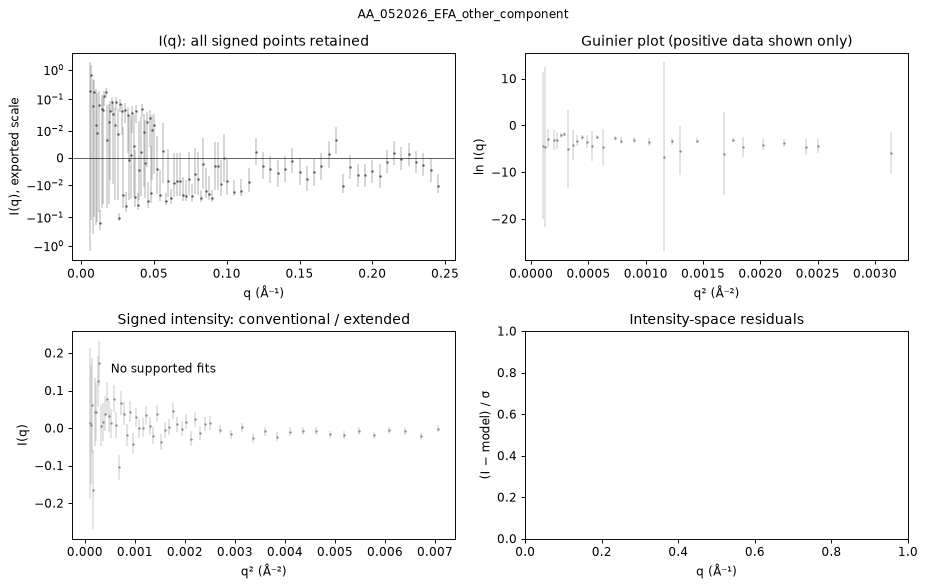

Component identity and physical validity are not established by a converged fit. No supported extended fit; do not interpret as a species Rg.

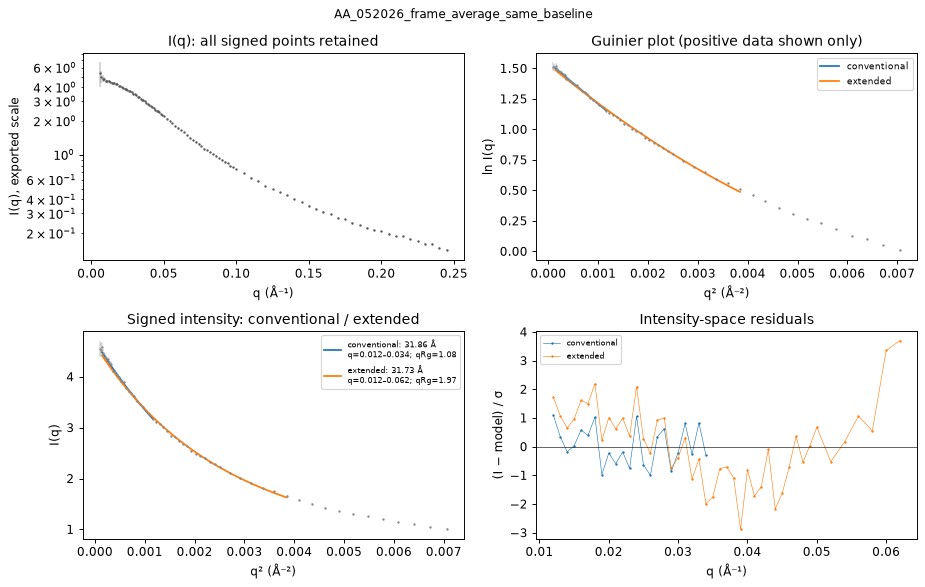

Component identity and physical validity are not established by a converged fit.

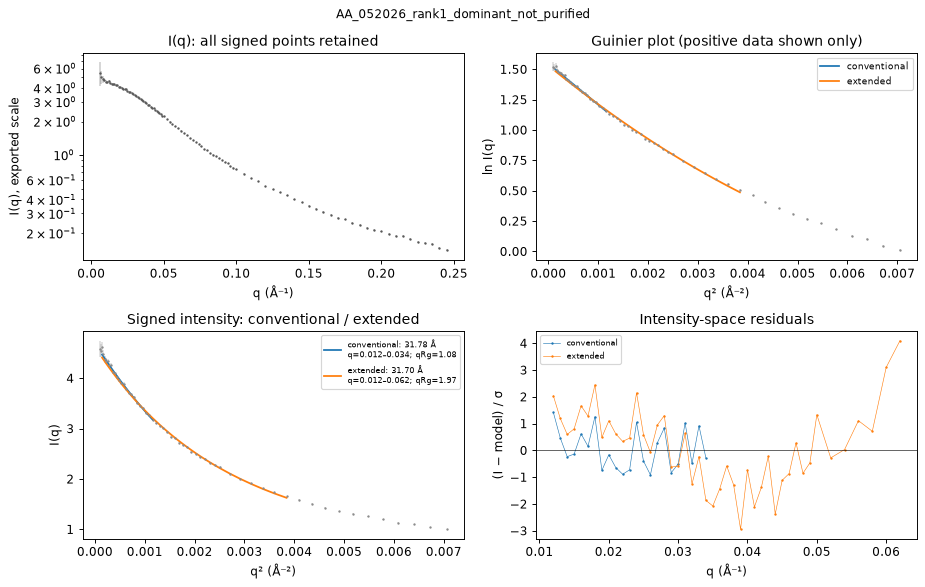

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

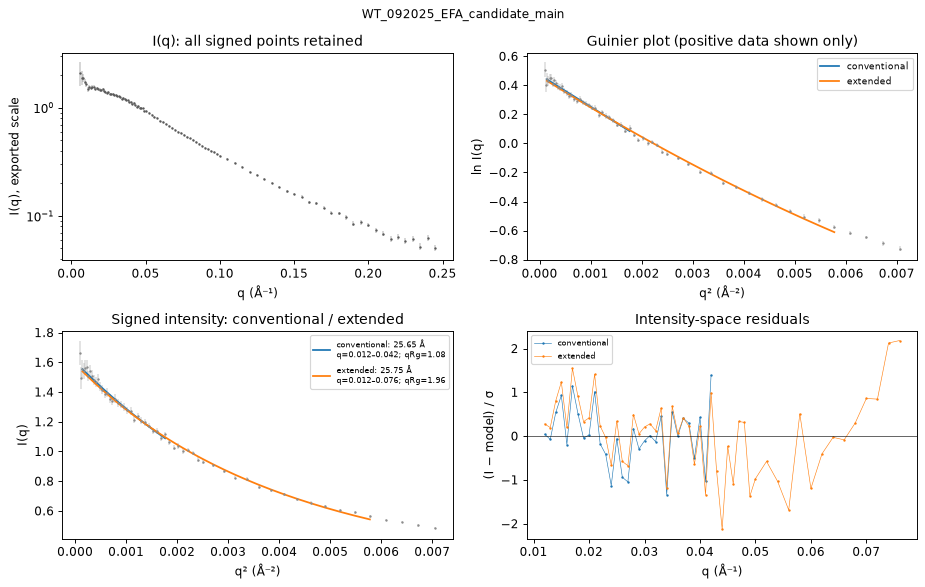

Component identity and physical validity are not established by a converged fit.

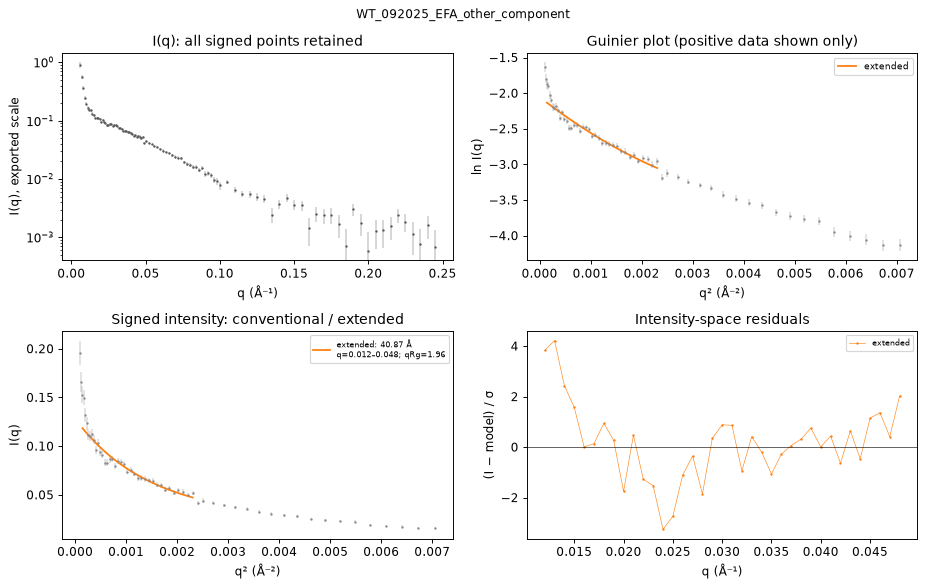

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

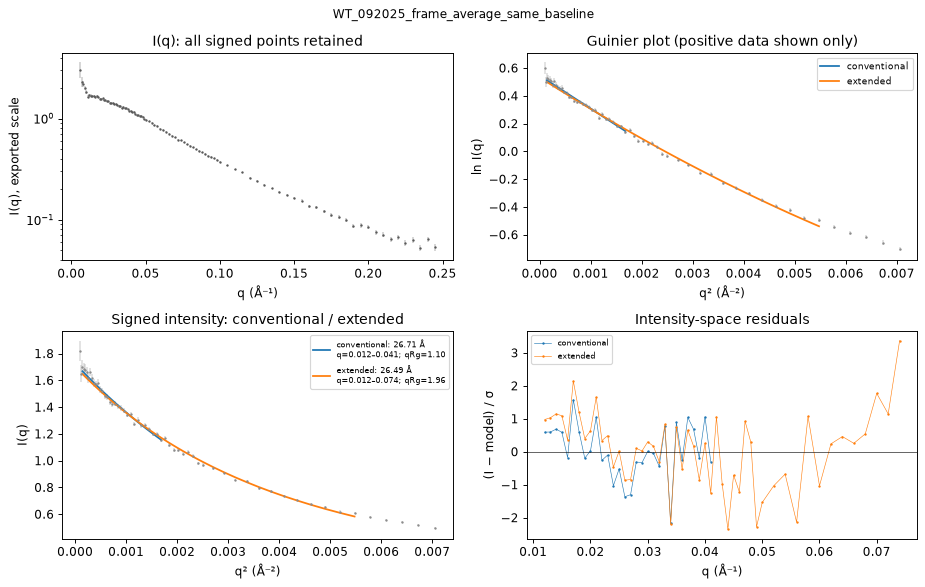

Component identity and physical validity are not established by a converged fit.

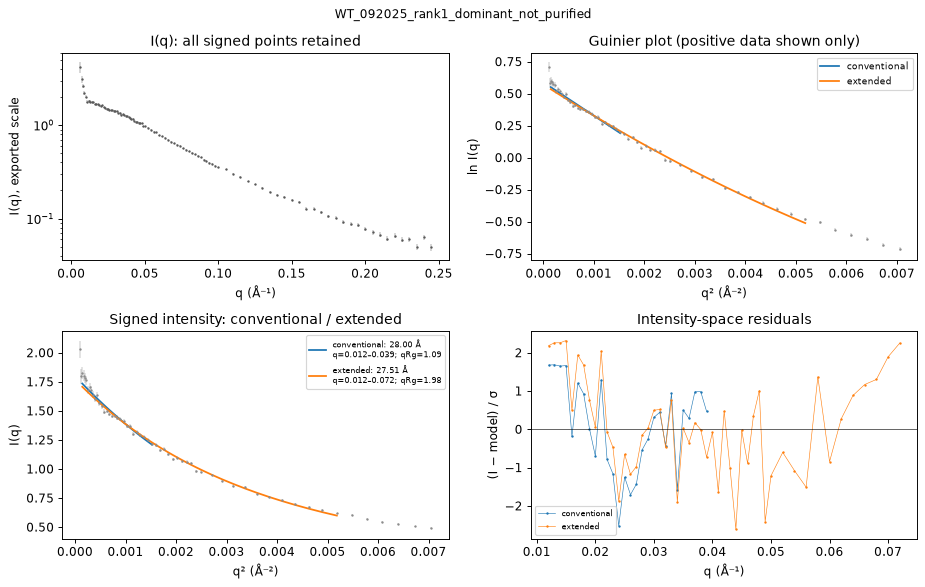

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|AA_052026_EFA_candidate_main|31.34 ± 0.52|32.55 ± 0.61|31.23 ± 0.15|[31.03, 31.72]|
|AA_052026_EFA_other_component|unsupported|unsupported|unsupported|unsupported|
|AA_052026_frame_average_same_baseline|31.86 ± 0.29|33.18 ± 0.34|31.73 ± 0.09|[31.57, 31.87]|
|AA_052026_rank1_dominant_not_purified|31.78 ± 0.28|33.09 ± 0.33|31.70 ± 0.08|[31.53, 31.86]|
|WT_092025_EFA_candidate_main|25.65 ± 0.44|26.44 ± 0.50|25.75 ± 0.15|[25.38, 26.04]|
|WT_092025_EFA_other_component|unsupported|unsupported|40.87 ± 0.88|[39.15, 42.86]|
|WT_092025_frame_average_same_baseline|26.71 ± 0.37|27.60 ± 0.42|26.49 ± 0.12|[26.27, 26.78]|
|WT_092025_rank1_dominant_not_purified|28.00 ± 0.39|28.98 ± 0.45|27.51 ± 0.13|[27.26, 27.74]|


In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Audited EFA and matched average'])